In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import os

DATA_DIR = '../数据'
df = pd.read_csv(os.path.join(DATA_DIR, 'processed_jobs.csv'))

df['高薪'] = (df['月薪均值'] >= 2).astype(int)
df['高薪'].value_counts()

高薪
0    1319
1     877
Name: count, dtype: int64

In [2]:
feature_cols = ['经验年限_标准化', '学历编码_标准化', '规模编码_标准化', '薪资月数_标准化'] + \
               [c for c in df.columns if c.startswith('城市_')] + \
               [c for c in df.columns if c.startswith('行业分组_')] + \
               [c for c in df.columns if c.startswith('公司性质_')]

X = df[feature_cols]
y = df['高薪']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape

((1756, 38), (440, 38))

#### 逻辑回归模型

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve

lr_clf = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_clf.fit(X_train, y_train)
pred_lr = lr_clf.predict(X_test)
proba_lr = lr_clf.predict_proba(X_test)[:, 1]

acc_lr = accuracy_score(y_test, pred_lr)
f1_lr = f1_score(y_test, pred_lr)
auc_lr = roc_auc_score(y_test, proba_lr)
acc_lr, f1_lr, auc_lr

(0.7386363636363636, 0.6981627296587927, 0.8021156163911846)

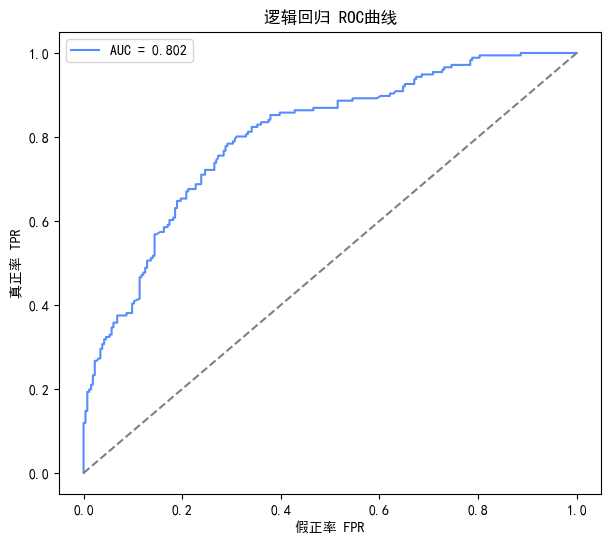

In [4]:
# ROC曲线
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

fpr, tpr, thresholds = roc_curve(y_test, proba_lr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_lr:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('假正率 FPR')
plt.ylabel('真正率 TPR')
plt.title('逻辑回归 ROC曲线')
plt.legend()
plt.show()

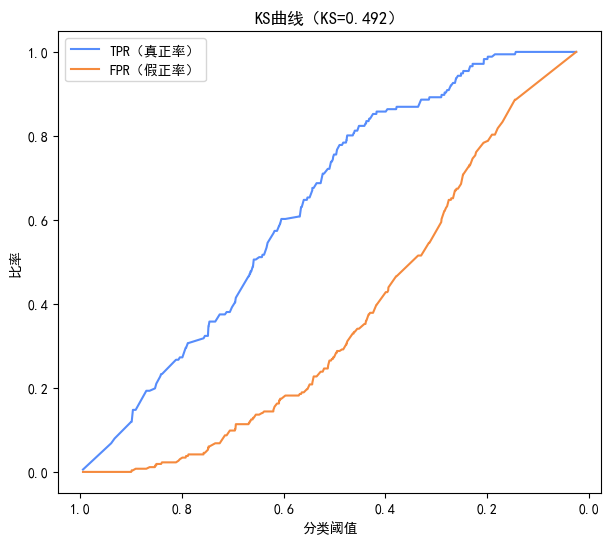

In [5]:
# KS曲线
ks_values = tpr - fpr
ks_stat = ks_values.max()

plt.figure(figsize=(7, 6))
plt.plot(thresholds[1:], tpr[1:], label='TPR（真正率）')
plt.plot(thresholds[1:], fpr[1:], label='FPR（假正率）')
plt.gca().invert_xaxis()
plt.xlabel('分类阈值')
plt.ylabel('比率')
plt.title(f'KS曲线（KS={ks_stat:.3f}）')
plt.legend()
plt.show()

####  决策树模型

In [6]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt_clf = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
dt_clf.fit(X_train, y_train)
pred_dt = dt_clf.predict(X_test)
proba_dt = dt_clf.predict_proba(X_test)[:, 1]

acc_dt = accuracy_score(y_test, pred_dt)
f1_dt = f1_score(y_test, pred_dt)
auc_dt = roc_auc_score(y_test, proba_dt)
acc_dt, f1_dt, auc_dt

(0.7045454545454546, 0.622093023255814, 0.7406917183195592)

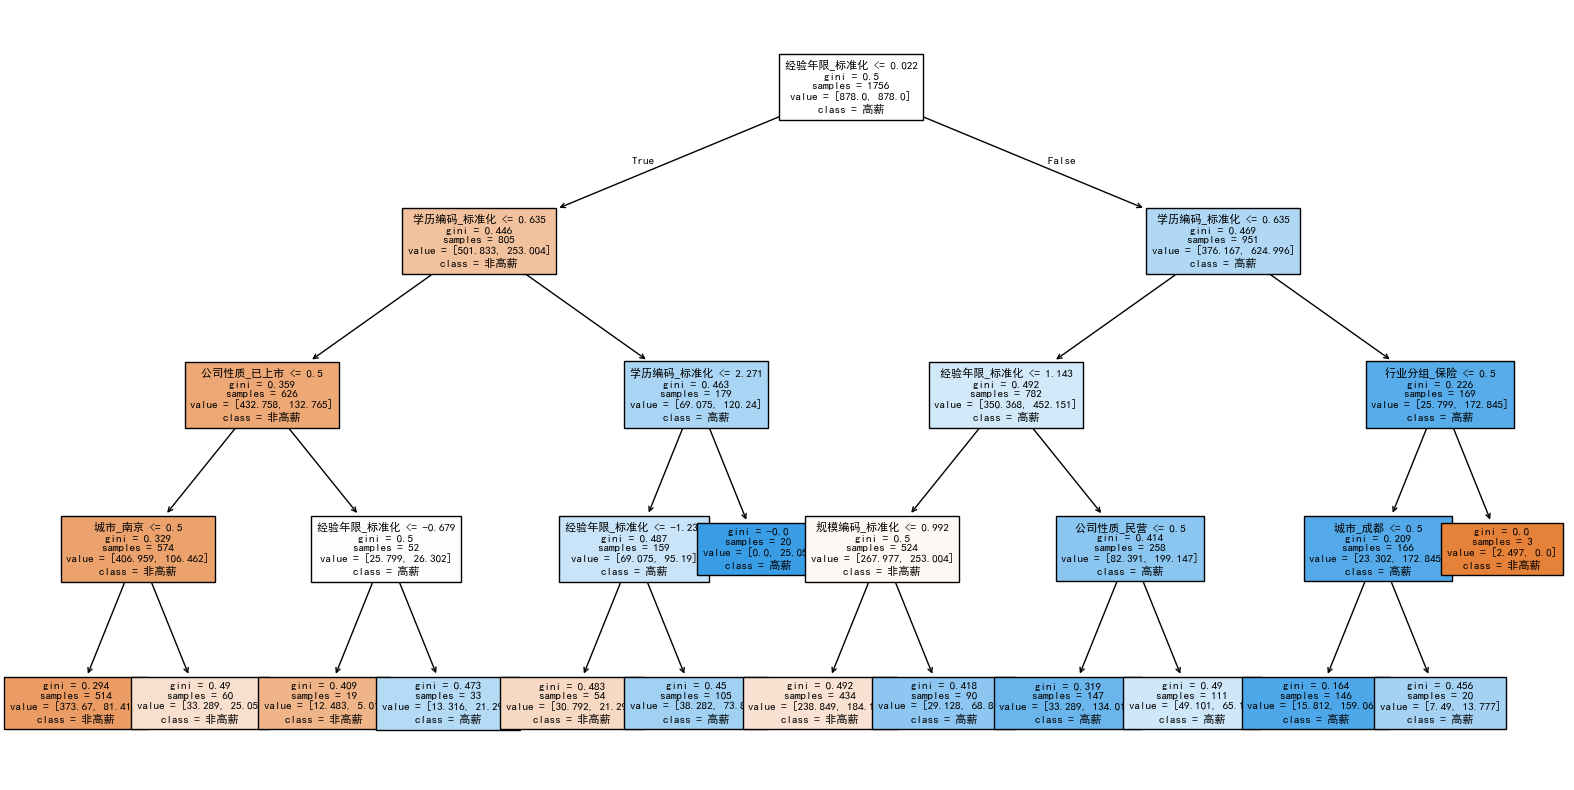

In [7]:
plt.figure(figsize=(20, 10))
plot_tree(dt_clf, feature_names=feature_cols, class_names=['非高薪', '高薪'], filled=True, fontsize=8)
plt.show()

In [8]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(dt_clf, X_train, y_train, cv=5, scoring='accuracy')
cv_scores, cv_scores.mean()

(array([0.73579545, 0.66381766, 0.67806268, 0.7037037 , 0.73219373]),
 np.float64(0.7027146464646465))